# Ecommerce Customer Segmentation And Prediction

## Objectives:
1. Enhance marketing strategies and customer retention by identifying distinct customer segments.
2. Use machine learning to segment customers and predict future purchase activity


## Read and Preprocess Data

In [163]:
import pandas as pd
import numpy as np

In [164]:
sales_data = pd.read_csv('data/data.csv', encoding='latin-1')
sales_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [165]:
sales_data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


## Data Preprocessing

### Check Null Values

In [166]:
sales_data.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [167]:
customerID_missing_percentage = sales_data.CustomerID.isna().sum() / len(sales_data) * 100
print(f"Missing data percentage (for customerID): {customerID_missing_percentage:.2f}%")

Missing data percentage (for customerID): 24.93%


In [168]:
sales_data.CustomerID.value_counts()

CustomerID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
           ... 
18184.0       1
13256.0       1
13017.0       1
18174.0       1
15195.0       1
Name: count, Length: 4372, dtype: int64

Records which have no Customer ID and no Description are likely to be zero-spend null records.

In [169]:
def describe_description_customer_nulls(df, target_cols):

    # Count nulls and flag rows missing both Description and CustomerID.
    missing_counts = df[target_cols].isna().sum()
    for col, count in missing_counts.items():
        print(f"{col} null records: {count}")

    null_records_mask = df[target_cols].isna().all(axis=1)
    common_zerovalue_records = df[null_records_mask]
    print(f"Records with both Description and CustomerID null: {len(common_zerovalue_records)}")

    
    cleaned_df = df[~null_records_mask].copy()
    print("Deleted zero-spend null records")
    return common_zerovalue_records, cleaned_df


In [170]:
_  , cleaned_df = describe_description_customer_nulls(sales_data, ["Description", "CustomerID"])

Description null records: 1454
CustomerID null records: 135080
Records with both Description and CustomerID null: 1454
Deleted zero-spend null records


In [171]:
cleaned_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [172]:
cleaned_df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

Map CustomerID with InvoiceNo to identify how many customers have **multiple transactions** and better understand customer *spending patterns*.

In [173]:
def classify_customer_orders(df: pd.DataFrame):
    """Classify customers based on number of unique invoices."""
    
    customer_invoice_counts = (
        df.groupby("CustomerID")["InvoiceNo"]
          .nunique()
          .reset_index(name="invoice_count")
    )
    
    customer_invoice_counts["order_type"] = customer_invoice_counts["invoice_count"].apply(
        lambda x: "single_invoice" if x == 1 else "multiple_invoices"
    )
    
    return customer_invoice_counts

In [174]:
customer_invoice_map_df = classify_customer_orders(cleaned_df)
customer_invoice_map_df.order_type.value_counts()

order_type
multiple_invoices    3059
single_invoice       1313
Name: count, dtype: int64

This means a lot of customers have multiple invoices associated with them than a one-to-one relationship.

In [175]:
customer_missing_mask = cleaned_df.CustomerID.isna()
customer_missing_df = cleaned_df[customer_missing_mask].copy()
customer_missing_df.to_csv('data/unknown_customer_data.csv',sep=',')

In [176]:
cleaned_df['CustomerID'] = cleaned_df.CustomerID.fillna(0).astype('Int64')

Fill na values in the 'CustomerID' column with 0 and convert the column to integer type for easier analysis.

In [177]:
cleaned_df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [178]:
print("Number of unique customers :", len(list(cleaned_df.CustomerID.value_counts())))

Number of unique customers : 4373


In [179]:
print("Number of total countries :", len(list(cleaned_df.Country.value_counts())))

Number of total countries : 39


In [180]:
print("Number of missing unit prices :", cleaned_df.UnitPrice.eq(0.0).sum())

Number of missing unit prices : 1061


In [181]:
free_items_df= cleaned_df[cleaned_df.UnitPrice.eq(0.0)]
free_items_df.to_csv("data/free_items.csv", sep=',')

In [182]:
cleaned_df["IsPromotion"] = (cleaned_df["UnitPrice"] == 0.0).astype(int)
cleaned_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsPromotion
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,0
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France,0


In [183]:
cleaned_df["IsPromotion"].value_counts()

IsPromotion
0    539394
1      1061
Name: count, dtype: int64

## Feature Engineering

1. Clean the 'InvoiceDate' column and convert it to datetime format.
2. Add a 'TotalAmount' column which will contain total amount for each product (Quantity * UnitPrice).
3. Add RFM features:
   - **Recency**: Number of days since the last purchase.
        - How fresh is the transaction
   - **Frequency**: Total number of transactions.
        - How often do they purchase
   - **Monetary**: Total amount spent by the customer.
        - How much value do they bring

In [184]:
cleaned_df["InvoiceDate"] = pd.to_datetime(cleaned_df["InvoiceDate"])
cleaned_df["TotalAmount"] = cleaned_df["Quantity"] * cleaned_df["UnitPrice"]

In [185]:
def aggregate_rfm_data(df: pd.DataFrame):
    snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

    #Remove promotions from RFM data to avoid non-revenue generating items
    cleaned_no_promo_df = df[df.UnitPrice > 0]

    rfm = cleaned_no_promo_df.groupby("CustomerID").agg({
        "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
        "InvoiceNo": "nunique",
        "TotalAmount": "sum"
    }).reset_index()

    rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

    rfm = rfm[rfm["Monetary"] > 0]

    rfm['AvgOrderValue']  = (rfm['Monetary'] / rfm['Frequency'])

    return rfm

In [186]:
rfm_data = aggregate_rfm_data(cleaned_df)
rfm_data

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,0,1,1610,1469806.24,912.923130
2,12347,2,7,4310.00,615.714286
3,12348,75,4,1797.24,449.310000
4,12349,19,1,1757.55,1757.550000
5,12350,310,1,334.40,334.400000
...,...,...,...,...,...
4367,18280,278,1,180.60,180.600000
4368,18281,181,1,80.82,80.820000
4369,18282,8,3,176.60,58.866667
4370,18283,4,16,2094.88,130.930000


### Exploratory Data Analysis (EDA)

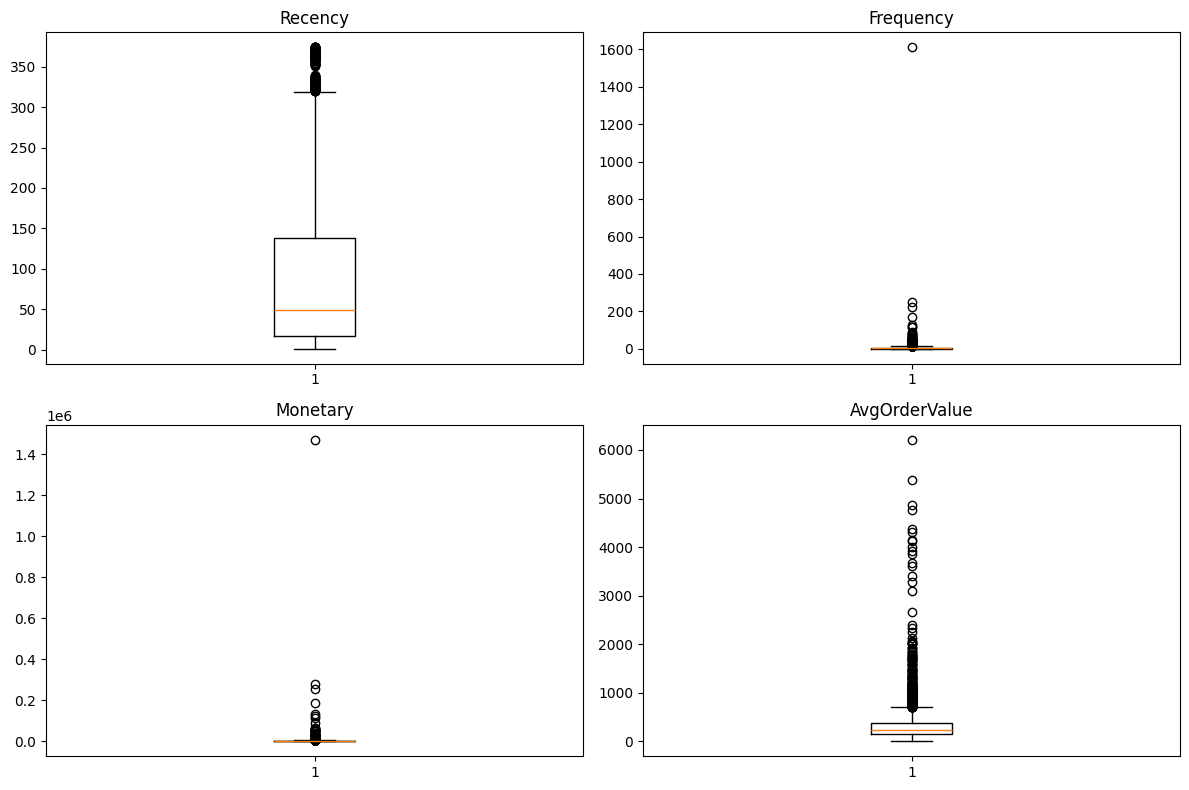

In [187]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(12, 8))

for i, feature in enumerate(["Recency", "Frequency", "Monetary", "AvgOrderValue"], 1):
    plt.subplot(2, 2, i)
    plt.boxplot(rfm_data[feature])
    plt.title(feature)

plt.tight_layout()
plt.yscale('linear')
plt.show()

## Normalization and Scaling
Perform transformation for Monetary feature to reduce distribution skewness.

**Why?**

A few customers spend massively more than others. This can skew the clustering results, as K-Means is sensitive to outliers. By applying a log transformation, we can reduce the impact of these high-spending customers and create more balanced clusters.

In [188]:
from sklearn.preprocessing import RobustScaler, PowerTransformer

features = rfm_data.columns.difference(['CustomerID'])

def normalize_rfm(rfm): 
    print(rfm.describe())

    rfm["Monetary"] = rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(0.99))
    rfm["Frequency"] = rfm["Frequency"].clip(upper=rfm["Frequency"].quantile(0.99))
    rfm["AvgOrderValue"] = rfm["AvgOrderValue"].clip(upper=rfm["AvgOrderValue"].quantile(0.99))

    pt = PowerTransformer(method='yeo-johnson')
    X_pt = pt.fit_transform(rfm[features])

In [189]:
normalize_rfm(rfm_data)
rfm_data.isna().sum() # Final null check

         CustomerID      Recency    Frequency      Monetary  AvgOrderValue
count        4323.0  4323.000000  4323.000000  4.323000e+03   4.323000e+03
mean   15294.995605    90.322924     5.486236  2.263035e+03   3.223086e+02
std     1736.989704    99.131410    26.147979  2.380516e+04   3.515916e+02
min             0.0     1.000000     1.000000  1.776357e-15   8.881784e-16
25%         13811.5    17.000000     1.000000  3.023150e+02   1.545170e+02
50%         15297.0    49.000000     3.000000  6.578000e+02   2.396460e+02
75%         16777.5   138.000000     6.000000  1.626550e+03   3.726993e+02
max         18287.0   374.000000  1610.000000  1.469806e+06   6.207670e+03


CustomerID       0
Recency          0
Frequency        0
Monetary         0
AvgOrderValue    0
dtype: int64

In [190]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(rfm_data[features])

## Model Building :- Clustering

In [191]:
def label_clusters(rfm_df : pd.DataFrame , cluster_column : str = "Cluster"):
#TODO
    df = rfm_df.copy()

    # Compute cluster-level means
    cluster_summary = df.groupby(cluster_column)[
        ["Recency", "Frequency", "Monetary"]
    ].mean().round(2)

    print(cluster_summary)

        # Step 2: Compute thresholds (quantiles for robustness)
    r_q_low, r_q_high = cluster_summary["Recency"].quantile([0.33, 0.66])
    f_q_low, f_q_high = cluster_summary["Frequency"].quantile([0.33, 0.66])
    m_q_low, m_q_high = cluster_summary["Monetary"].quantile([0.33, 0.66])

    # Step 3: Rule-based labeling
    def assign_label(row):
        r, f, m = row["Recency"], row["Frequency"], row["Monetary"]

        # Best customers
        if (r <= r_q_low) and (f >= f_q_high) and (m >= m_q_high):
            return "VIP"

        # Active good customers
        if (r <= r_q_low) and (m >= m_q_low):
            return "Active"

        # Potential customers
        if (r <= r_q_high) and (f >= f_q_low):
            return "Potential"

        # At risk customers
        if (r > r_q_high) and (m >= m_q_low):
            return "At Risk"

        # Churned customers
        if (r > r_q_high):
            return "Churned"

        return "Low Value"

    # Apply labels to cluster summary
    cluster_summary["Segment"] = cluster_summary.apply(assign_label, axis=1)

    # Map labels back to original dataframe
    df["Segment"] = df[cluster_column].map(cluster_summary['Segment'])
    
    df.drop(columns=[cluster_column], inplace=True)

    return df

### K-Means Clustering

K-Means clustering is good for customer segmentations as it can group customer data based on their RFM values, allowing us to identify distinct customer segments with similar purchasing behaviors.

In [192]:
from sklearn.cluster import KMeans

kmc_model = KMeans(n_clusters=4, random_state=42) 
rfm_data['Cluster_Kmeans'] = kmc_model.fit_predict(X_scaled)

In [193]:
rfm_data = label_clusters(rfm_data, "Cluster_Kmeans")
rfm_data

                Recency  Frequency  Monetary
Cluster_Kmeans                              
0                245.28       1.70    356.91
1                 35.22      11.62   4158.02
2                 44.94       3.53    845.51
3                 11.96      27.13  15151.97


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment
0,0,1,37.56,18356.8876,912.923130,VIP
2,12347,2,7.00,4310.0000,615.714286,Potential
3,12348,75,4.00,1797.2400,449.310000,At Risk
4,12349,19,1.00,1757.5500,1682.641422,Potential
5,12350,310,1.00,334.4000,334.400000,Churned
...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned
4368,18281,181,1.00,80.8200,80.820000,Churned
4369,18282,8,3.00,176.6000,58.866667,At Risk
4370,18283,4,16.00,2094.8800,130.930000,Potential


In [194]:
print(rfm_data.Segment.value_counts())

Segment
At Risk      2572
Churned      1026
Potential     625
VIP           100
Name: count, dtype: int64


#### Evaluate Clusters - Kmeans

In [195]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=45)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"{k}, score:{score:.4f}")

2, score:0.7373
3, score:0.4992
4, score:0.4866
5, score:0.3840


Silhouette score shows 4 clusters will give a good balance of cluster separation.

### Gausian Mixture Model Clustering

In [213]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=4,     
    covariance_type='full',
    reg_covar=1e-3,
    random_state=42)

rfm_data["Cluster_GMM"] = gmm.fit_predict(X_scaled)

print("-------------- Model Fit Summary: ---------------")
print(f"\tNumber of components: {gmm.get_params()['n_components']}")
print(f"\tConvergence achieved: {gmm.converged_}")
print("-------------------------------------------------")

-------------- Model Fit Summary: ---------------
	Number of components: 4
	Convergence achieved: True
-------------------------------------------------


#### Log-likelihood measures:
> “How probable is this customer under the learned distribution?”

In [197]:
risk_score = - ( gmm.score_samples(X_scaled) )

print(f"Risk score range: {risk_score.min():.4f} to {risk_score.max():.4f}")

Risk score range: -0.7432 to 104.3404


In [214]:
def build_risk_profiles(df: pd.DataFrame, risk_score: np.ndarray):

    # Normalize risk scores to a 0-1 scale for better interpretability
    norm_risk = (
        (risk_score - risk_score.min()) 
        / 
        (risk_score.max() - risk_score.min())
    )

    q50, q95 = np.quantile(norm_risk, (0.50, 0.95))

    df["RiskProfile"] = np.where(
        norm_risk <= q50, "Low Risk",
        np.where(
            norm_risk <= q95, "Medium Risk",
            "High Risk"
        )

    )

    print(df.RiskProfile.value_counts())

    return df

In [215]:
# Only Risk scoring, no labelling for GMM
rfm_data = build_risk_profiles(rfm_data, risk_score)
rfm_data

RiskProfile
Low Risk       2162
Medium Risk    1944
High Risk       217
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment | Risk,Cluster_GMM,RiskProfile
0,0,1,37.56,18356.8876,912.923130,VIP --- High Risk,3,High Risk
2,12347,2,7.00,4310.0000,615.714286,Potential --- Medium Risk,3,Medium Risk
3,12348,75,4.00,1797.2400,449.310000,At Risk --- Medium Risk,2,Medium Risk
4,12349,19,1.00,1757.5500,1682.641422,Potential --- High Risk,1,High Risk
5,12350,310,1.00,334.4000,334.400000,Churned --- Low Risk,0,Low Risk
...,...,...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned --- Low Risk,0,Low Risk
4368,18281,181,1.00,80.8200,80.820000,Churned --- Low Risk,0,Low Risk
4369,18282,8,3.00,176.6000,58.866667,At Risk --- Medium Risk,2,Medium Risk
4370,18283,4,16.00,2094.8800,130.930000,Potential --- Medium Risk,3,Medium Risk


#### Evaluate GMM Clusters

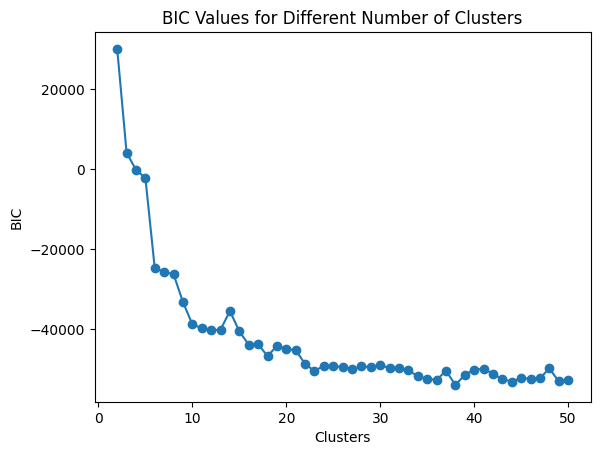

In [227]:
bic_scores = []
k_range = range(2, 51)

for k in k_range:
    gmm_2 = GaussianMixture(n_components=k, random_state=45, covariance_type='full')
    gmm_2.fit(X_scaled)
    bic_scores.append(gmm_2.bic(X_scaled))

import matplotlib.pyplot as plt
plt.plot(k_range, bic_scores, marker='o')
plt.xlabel("Clusters")
plt.ylabel("BIC")
plt.title("BIC Values for Different Number of Clusters")
plt.show()

In [231]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    gmm_ss = GaussianMixture(n_components=k, random_state=45, covariance_type='full')
    gmm_labels = gmm_ss.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, gmm_labels)
    print(f"{k}, score:{score:.4f}")

2, score:0.3883
3, score:0.1085
4, score:0.0537
5, score:0.0773
6, score:0.0230
7, score:0.0358
8, score:0.0219
9, score:0.0139
10, score:0.0070


Kmeans and GMM have similar silhoutte score for 4 clusters, but GMM can capture more complex cluster shapes and may provide better segmentation in cases where clusters are not well-separated.

In our case, we will use Kmeans for core segmentation, and GMM can be used for risk profiling to identify customers who are at risk of churning. 

#### Mapping Risk Profiles to Business Segments

In [203]:
seg_risk_matrix_pct = pd.crosstab(rfm_data["Segment"], rfm_data["RiskProfile"],  normalize='index') * 100
print(seg_risk_matrix_pct.round(2))

RiskProfile  High Risk  Low Risk  Medium Risk
Segment                                      
At Risk           0.70     58.98        40.32
Churned           2.53     62.87        34.60
Potential        14.72      0.00        85.28
VIP              81.00      0.00        19.00


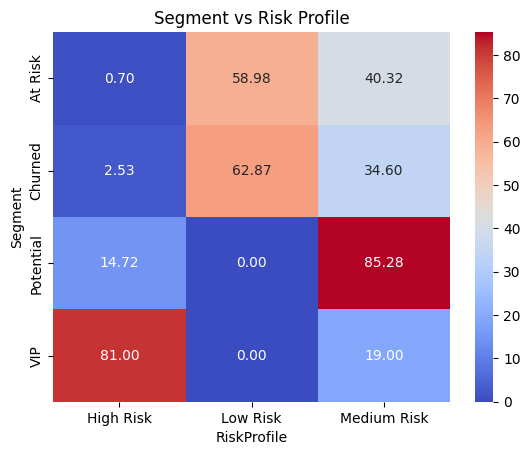

In [204]:
sb.heatmap(seg_risk_matrix_pct, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Segment vs Risk Profile")
plt.show()

🟢 VIP + Low Risk:

Stable high-value customers
Consistent behavior
👉 Action:
Loyalty rewards
Premium upsell

🟡 VIP + Medium Risk:

Slight behavioral drift
Early warning
👉 Action:
Personalized nudges
Engagement campaigns

🔴 VIP + High Risk:
🚨 MOST IMPORTANT SEGMENT

High value but deviating behavior
👉 Action:
Immediate intervention
High-touch retention (calls, exclusive offers)
🚀 Potential Segment

<hr>

🟢 Potential + Low Risk:

Stable mid-value customers
Growth opportunity
👉 Action:
Cross-sell / bundles

🟡 Potential + Medium Risk:

Inconsistent engagement
👉 Action:
Incentives to increase frequency

🔴 Potential + High Risk:

Dropping before converting to high value
👉 Action:
Strong nudges
Personalized recommendations


<hr>
🟢 At Risk + Low Risk:

Temporarily inactive but stable
👉 Action:
Light reminders

🟡 At Risk + Medium Risk:

Clear decline
👉 Action:
Win-back campaigns

🔴 At Risk + High Risk:

🚨 Likely churn soon
👉 Action:
Aggressive retention offers


<hr>
🟢 Churned + Low Risk:

Stable inactivity
👉 Action:
Low priority reactivation

🟡 Churned + Medium Risk:

Some residual engagement
👉 Action:
Targeted reactivation

🔴 Churned + High Risk:

Completely disengaged / erratic
👉 Action:
Suppress or last-attempt campaigns

## Model Building :- Predictive Classifier

In [205]:
rfm_data

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,Segment,Cluster_GMM,RiskProfile
0,0,1,37.56,18356.8876,912.923130,VIP,3,High Risk
2,12347,2,7.00,4310.0000,615.714286,Potential,3,Medium Risk
3,12348,75,4.00,1797.2400,449.310000,At Risk,2,Medium Risk
4,12349,19,1.00,1757.5500,1682.641422,Potential,1,High Risk
5,12350,310,1.00,334.4000,334.400000,Churned,0,Low Risk
...,...,...,...,...,...,...,...,...
4367,18280,278,1.00,180.6000,180.600000,Churned,0,Low Risk
4368,18281,181,1.00,80.8200,80.820000,Churned,0,Low Risk
4369,18282,8,3.00,176.6000,58.866667,At Risk,2,Medium Risk
4370,18283,4,16.00,2094.8800,130.930000,Potential,3,Medium Risk


New Feature for Classifier: "Segment | Risk" which combines the segment and risk profile into a single feature for classification.

In [206]:
rfm_data["Segment | Risk"] = rfm_data["Segment"] + " --- " + rfm_data["RiskProfile"]
rfm_data.drop(columns=["Cluster_GMM", "RiskProfile", "Segment"], inplace=True)

### Train Test Split

In [207]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC 

In [208]:
X = rfm_data.drop(columns=["CustomerID", "Segment | Risk"])
y = rfm_data["Segment | Risk"]

In [209]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, random_state=36, stratify=y)
print(X_train.shape, X_test.shape)

(3242, 4) (1081, 4)


### Model Fitting and Evaluation

In [210]:
def fit_model(model, X_train, y_train, X_test, y_test, name="Model"):
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"{''.join('\u0332'.join(name))} fitted succesfully. \nResults:")
    print(f"Train Accuracy: {train_score:.4f}, \nTest Accuracy: {test_score:.4f}")
    print("-" * 60)

    return model

In [233]:
rfc_fit = fit_model(RandomForestClassifier(
    random_state=62,
    max_depth=5,
    max_features='sqrt'
    ), X_train, y_train, X_test, y_test, name="Random Forest")

gbc_fit = fit_model(GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,
    learning_rate=0.13,
    ), X_train, y_train, X_test, y_test, name="Gradient Boost")

svc_fit = fit_model(SVC(random_state=42), X_train, y_train, X_test, y_test, name="SVMC")

R̲a̲n̲d̲o̲m̲ ̲F̲o̲r̲e̲s̲t fitted succesfully. 
Results:
Train Accuracy: 0.9001, 
Test Accuracy: 0.8686
------------------------------------------------------------
G̲r̲a̲d̲i̲e̲n̲t̲ ̲B̲o̲o̲s̲t fitted succesfully. 
Results:
Train Accuracy: 0.9960, 
Test Accuracy: 0.9473
------------------------------------------------------------
S̲V̲M̲C fitted succesfully. 
Results:
Train Accuracy: 0.8871, 
Test Accuracy: 0.8788
------------------------------------------------------------


In [234]:
y_pred = gbc_fit.predict(X_test)

In [236]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred, zero_division=0))
print(confusion_matrix(y_test, y_pred))

                           precision    recall  f1-score   support

    At Risk --- High Risk       0.00      0.00      0.00         5
     At Risk --- Low Risk       0.96      0.98      0.97       379
  At Risk --- Medium Risk       0.94      0.93      0.94       259
    Churned --- High Risk       0.86      0.86      0.86         7
     Churned --- Low Risk       0.96      0.98      0.97       161
  Churned --- Medium Risk       0.93      0.91      0.92        89
  Potential --- High Risk       0.89      0.74      0.81        23
Potential --- Medium Risk       0.93      0.97      0.95       133
        VIP --- High Risk       0.90      0.95      0.93        20
      VIP --- Medium Risk       0.75      0.60      0.67         5

                 accuracy                           0.95      1081
                macro avg       0.81      0.79      0.80      1081
             weighted avg       0.94      0.95      0.94      1081

[[  0   0   4   0   0   0   0   1   0   0]
 [  0 370   9   

### Conclusion: 
We will use Gradient Boosting as our default classifier as this model returned better accuracy (95%). 